Здесь я экспериментирую с feature extraction. Я и тренирую здесь простые модели, но только для оценки полезности признаков, разработкой собственно модели можно будет заняться только позднее.

In [1]:
import polars as pl
dataset = pl.read_csv(
    '../data/processed/train.csv'
)


In [2]:
SEED = 42


In [48]:
dataset.columns


['StimSite',
 'Stimulus',
 'RT_start',
 'Response_annot',
 'Response_transcription_annot',
 'Error_type_annot',
 'error_type_label']

In [49]:
dataset_0 = dataset[[
    'Stimulus',
    'RT_start',
    'Response_annot',
    'Response_transcription_annot',
    'error_type_label'
    ]]

dataset_0[['RT_start']] = dataset_0[['RT_start']]\
                          .fill_null(strategy='zero')

dataset_0[['Response_annot']] = dataset_0[['Response_annot']]\
                        .fill_null('')

dataset_0[['Response_transcription_annot']] =\
      dataset_0[['Response_transcription_annot']].fill_null('')

# мы не хотим получать подсказки в виде #нрзб# и прочих особенностей
# разметки в транскрипте, т. к. они не всегда могут быть доступны
dataset_0 = dataset_0.with_columns(
    pl.col('Response_annot').str.to_lowercase()\
                            .str.strip_chars()\
                            .str.replace_all(r'[^а-яё ]', '')\
                            .str.replace_all(r'\s+', ' ')
                            .str.replace_all('нрзб', ''),
)


Различные способы заполнения слабо влияют на метрики по результатам части 1, но при заполнении нулями метрики для классов, которые ожидаемо выявляются по признаку `RT_start`, оказываются немного выше.

# 1. Длина ответа относительно длины стимула

In [50]:
dataset_1 = dataset_0.with_columns(
                            (pl.col('Response_annot').str.len_chars() /
                            pl.col('Stimulus').str.len_chars())\
                            .fill_null(0)\
                            .alias('relative_length')
                            )


In [4]:
from json import load

error_type_ids_file = open('../data/processed/error_type_ids.json',
                        'r', -1, 'utf-8')
error_type_ids = load(error_type_ids_file)
print(*error_type_ids.items(), sep='\n')
error_type_ids_to_names: list[str] = [''] * 8
for k, v in error_type_ids.items():
    error_type_ids_to_names[v] = k


('нет', 0)
('speech arrest', 1)
('аномия', 2)
('дизартрия', 3)
('задержка', 4)
('поиск слова', 5)
('семантическая парафазия', 6)
('фонетическая парафазия', 7)


In [52]:
X = dataset_1[['relative_length', 'RT_start']]
y = dataset_1['error_type_label']


In [5]:
from sklearn.tree import DecisionTreeClassifier

basic_model = DecisionTreeClassifier(random_state=SEED, max_depth=10)


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score,\
                                                    confusion_matrix
from matplotlib.pyplot import imshow, ylabel, xlabel, yticks, xticks
import numpy as np

def evaluate(X, y: pl.Series, estimator: Pipeline = Pipeline([
            ('classifier', basic_model)])
        ):
    # relative_length и RT_start — разного масштаба, для
    # линейных моделей здесь был бы скейлер
    k = 5
    stratified_k_fold = StratifiedKFold(n_splits = k, # test 20%
                                        shuffle = True,
                                        random_state=SEED)
    number_of_classes = y.n_unique()
    classes_met = y.unique().sort()
    error_type_ids_to_names_ = [name for i, name
                                in enumerate(error_type_ids_to_names)
                                if i in classes_met]

    f1s = np.zeros((k, number_of_classes))
    precisions = f1s.copy()
    recalls = f1s.copy()
    confusion_matrices = np.zeros((k, number_of_classes, 
                                   number_of_classes))
    
    for i, (train_mask, test_mask) in\
                    enumerate(stratified_k_fold.split(X, y)):
        X_train, X_test = X[train_mask], X[test_mask]
        y_train, y_test = y[train_mask], y[test_mask]
        estimator.fit(X_train, y_train)
        predictions = estimator.predict(X_test)
        f1s[i] = f1_score(y_test, predictions, average=None)
        precisions[i] = precision_score(y_test, predictions,
                                         average=None)
        recalls[i] = recall_score(y_test, predictions, average=None)
        confusion_matrices[i] = confusion_matrix(y_test, predictions)

    np.set_printoptions(suppress=True)

    def _tabs(cell):
        return cell + '\t' * (3 - len(cell) // 8)

    print('Класс\t\t\tPrec.\tRec.\tF1')
    print(*('%s%.4f\t%.4f\t%.4f' % (_tabs(name),
             precision.item(),
             recall.item(),
             f1.item())
            for name, precision, recall, f1
            in zip(error_type_ids_to_names_,
                   precisions.mean(axis=0),
                   recalls.mean(axis=0),
                   f1s.mean(axis=0))), 
            sep='\n')
    
    confusion_matrix_mean = confusion_matrices.mean(axis = 0).round(2)
    confusion_matrix_normalized = confusion_matrix_mean / \
                    confusion_matrix_mean.max(axis=1, keepdims=True)
    imshow(confusion_matrix_normalized)
    ylabel('Истина')
    xlabel('Предсказание')
    yticks(range(number_of_classes), error_type_ids_to_names_)
    xticks(range(number_of_classes), error_type_ids_to_names_, 
           rotation=45)
    return f1s.mean(axis=0), precisions.mean(axis=0), recalls.mean(axis=0)



c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-Individuals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-Individuals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-

Класс			Prec.	Rec.	F1
нет			0.9205	0.9864	0.9523
speech arrest		0.0000	0.0000	0.0000
аномия			0.8950	0.6357	0.7392
дизартрия		0.3275	0.0548	0.0936
задержка		0.6118	0.3514	0.4456
поиск слова		0.5024	0.1364	0.1989
семантическая парафазия	0.0286	0.0071	0.0114
фонетическая парафазия	0.0682	0.0078	0.0137


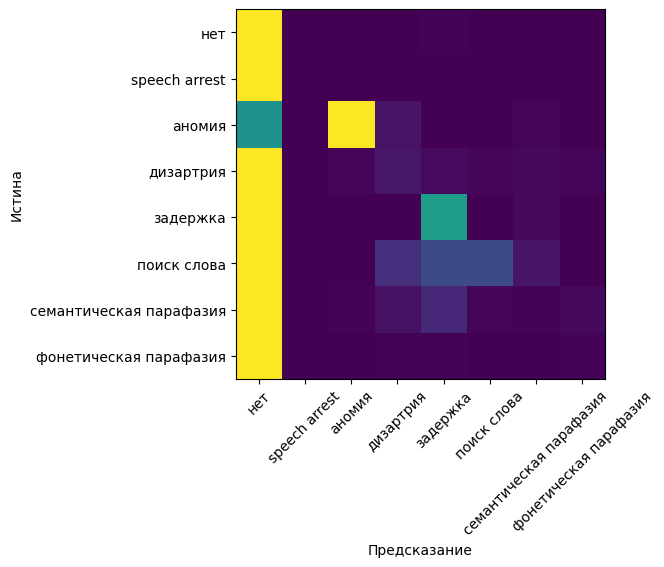

In [56]:
_ = evaluate(X, y)


# 2. Расстояние Левенштейна между стимулом и ответом

## Простейший случай
Сначала посмотрим на полезность доли вставок, удалений и замен. Доли, потому что стимулы могут быть разной длины, и для них будет в разной степени критично одно и то же абсолютное количество замен.

In [7]:
from rapidfuzz.distance import Levenshtein

def indelrep(stimulus, response) -> tuple[int, int, int]:
    edit_operations = Levenshtein.editops(stimulus, response)
    operation_counts = [0] * 3
    operation_ids = dict(zip(['insert', 'delete', 'replace'], range(3)))
    for tag, _, _ in edit_operations:
        operation_counts[operation_ids[tag]] += 1
    return tuple(count / len(stimulus) for count in operation_counts)

print(indelrep('роман', 'роамн'))


(0.2, 0.2, 0.0)


In [58]:
dataset_2 = dataset_1

In [59]:
dataset_2 = dataset_2.with_columns(
    pl.struct(['Stimulus', 'Response_annot'])
    .map_elements(
        lambda s: indelrep(s['Stimulus'], s['Response_annot']), 
        return_dtype=pl.Struct([
            pl.Field('insertions', pl.Float64),
            pl.Field('deletions', pl.Float64),
            pl.Field('replacements', pl.Float64)
        ])
    )
    .alias('edit_distance_components')
).unnest('edit_distance_components')


c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-Individuals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-Individuals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-

Класс			Prec.	Rec.	F1
нет			0.9287	0.9864	0.9566
speech arrest		0.0000	0.0000	0.0000
аномия			0.9378	0.6778	0.7829
дизартрия		0.3461	0.0710	0.1172
задержка		0.6470	0.3688	0.4684
поиск слова		0.4500	0.2030	0.2737
семантическая парафазия	0.2611	0.1148	0.1562
фонетическая парафазия	0.5835	0.2363	0.3314


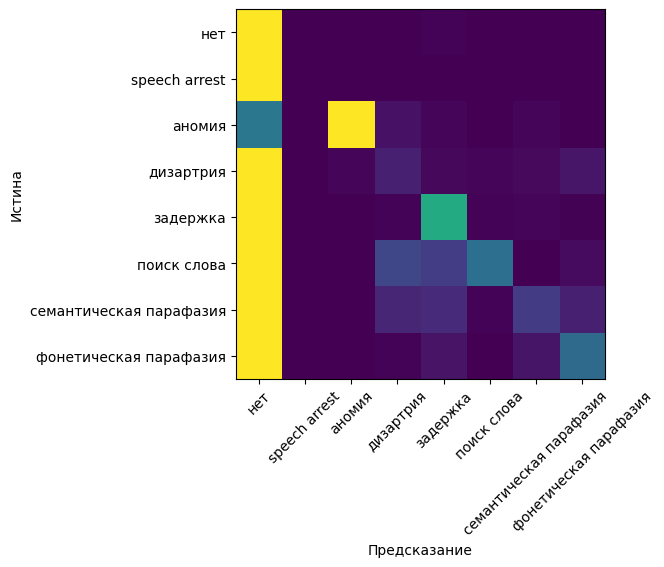

In [60]:
X = dataset_2[['RT_start', 'relative_length',
               'insertions', 'deletions', 'replacements']]
y = dataset_2['error_type_label']
_ = evaluate(X, y)


Отдельно проверим поинты, для которых есть транскрипция.

In [61]:
dataset_2_t = dataset_2\
    .filter(pl.col('Response_transcription_annot').str.len_chars() > 0)\
    .with_columns(
    pl.struct(['Stimulus', 'Response_transcription_annot'])
    .map_elements(
        lambda s: indelrep(s['Stimulus'],
                           s['Response_transcription_annot']), 
        return_dtype=pl.Struct([
            pl.Field('insertions_transcription', pl.Float64),
            pl.Field('deletions_transcription', pl.Float64),
            pl.Field('replacements_transcription', pl.Float64)
        ])
    )
    .alias('edit_distance_components_transcription')
).unnest('edit_distance_components_transcription')


Класс			Prec.	Rec.	F1
нет			0.1472	0.0964	0.1144
аномия			0.7678	0.8464	0.8016
дизартрия		0.3875	0.4443	0.4108
задержка		0.7369	0.7770	0.7554
поиск слова		0.2127	0.1745	0.1839
семантическая парафазия	0.2881	0.2695	0.2710
фонетическая парафазия	0.5043	0.3908	0.4380


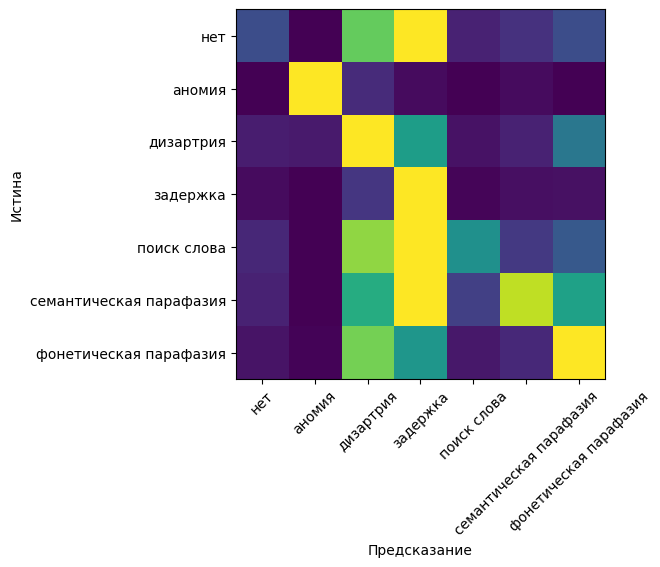

In [62]:
X = dataset_2_t[['RT_start', 'relative_length',
               'insertions', 'deletions', 'replacements']]
y = dataset_2_t['error_type_label']
_ = evaluate(X, y)


## Отдельные замены

Найдём самые частотные замены, оставим только их количество для каждого поинта, натренируем модель и посмотрим, как она справится. Тут возникнет две проблемы:
 + Матрица признаков будет разреженной; нужно будет или поднять порог частотности, или выбрать классификатор, который хорошо с таким работает.
 + Нужно писать свой трансформер для sklearn, потому что считать частотность по-хорошему надо каждый раз на тренировочной выборке, а не на датасете целиком, чтобы избежать утечки распределения. Это будет полезно позже, когда все операции над датасетом надо будет проводить в пайплайне.

In [63]:
def get_replacement_pairs(stimulus, response):
    return [(stimulus[i], response[j])
            for tag, i, j in Levenshtein.editops(stimulus, 
                                            response)
            if tag == 'replace']


In [64]:
get_replacement_pairs('штегрусым', 'это штеграсым')


[('у', 'а')]

In [8]:
from numpy import ndarray
from sklearn.base import BaseEstimator, TransformerMixin
from collections import Counter

class ReplacementCounter(BaseEstimator, TransformerMixin):
    def __init__(self, columns, max_features=10000,
                 use_transcription=False):
        self.columns = columns
        self.max_features = max_features
        self.use_transcription = use_transcription

    def _counts(self, X: pl.DataFrame | np.ndarray):
        if not ('Stimulus' in X.columns and\
                'Response_annot' in X.columns and\
                (not self.use_transcription or \
                 'Response_transcription_annot' in X.columns
                 )):
            raise TypeError('Нет ожидаемых колонок')
        new_rows = []
        for row in X\
            .with_row_index('id')\
            .to_dicts():
            pairs = Counter()
            pairs.update([f'replacements_{l1}_{l2}' \
                        for l1, l2 in get_replacement_pairs(
                                row['Stimulus'], row['Response_annot']
                            )])
            if self.use_transcription:
                pairs.update([f'replacements_{l1}_{l2}_t' \
                            for l1, l2 in get_replacement_pairs(
                                    row['Stimulus'],
                                    row['Response_transcription_annot']
                                )])
            row.update(pairs.items())
            new_rows.append(row)
        return pl.from_dicts(new_rows)
    
    def fit(self, X: pl.DataFrame | np.ndarray, y = None):
        if type(X) != pl.DataFrame:
            X = pl.from_numpy(X, self.columns)
        columns_before = X.columns
        columns_to_pass = ['Stimulus',
                            'Response_annot']
        if self.use_transcription:
            columns_to_pass += ['Response_transcription_annot']
        X = self._counts(X[columns_to_pass])
        self.top_columns = \
            X.select(pl.all()\
                .exclude(pl.String)\
                .sum()
            )\
            .unpivot()\
            .sort('value', descending=True)\
            .head(self.max_features + 1)
        # print(self.top_columns)
        self.feature_columns = self.top_columns\
            .get_column('variable')\
            .to_list()
        self.columns_to_leave = columns_before + self.feature_columns
        return self
    def transform(self, X):
        if type(X) != pl.DataFrame:
            X = pl.from_numpy(X, self.columns)
        counts = self._counts(X)
        counts = counts.with_columns(
                [pl.lit(None, dtype=pl.Int64).alias(c) 
                for c in self.feature_columns
                if c not in counts.columns]
            )\
            .select(self.feature_columns)
        # print(counts)
        return X.hstack(counts.drop('id'))\
            .fill_null(0)\
            .drop(pl.selectors.string())


In [66]:
replacement_counter = ReplacementCounter(dataset_2.columns)
replacement_counter.fit(dataset_2)
replacement_counter.transform(dataset_2[:20])


RT_start,error_type_label,relative_length,insertions,deletions,replacements,replacements_р_т,replacements_е_ё,replacements_а_и,replacements_к_т,replacements_е_и,replacements_к_н,replacements_я_е,replacements_е_,replacements_и_ы,replacements_р_о,replacements_б_ш,replacements_ю_а,replacements_л_т,replacements_б_,replacements_о_а,replacements_о_е,replacements_у_о,replacements_п_т,replacements_и_о,replacements_к_э,replacements_я_о,replacements_к_б,replacements_г_,replacements_у_ж,replacements_ш_а,replacements_к_в,replacements_у_ц,replacements_в_о,replacements_а_,replacements_а_м,replacements_к_е,replacements_ц_т,replacements_с_л,replacements_а_э,replacements_с_,replacements_о_т,replacements_б_л,replacements_в_э,replacements_л_ж,replacements_п_,replacements_у_к,replacements_ш_м,replacements_в_р,replacements_н_о,replacements_ж_к,replacements_к_ш,replacements_и_б,replacements_б_з,replacements_я_к,replacements_д_,replacements_м_и,replacements_с_к,replacements_д_э,replacements_о_э
i64,i64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
711,0,1.5,0.5,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
744,0,1.571429,0.571429,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
681,0,1.8,0.8,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1333,0,1.0,0.125,0.125,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1265,0,1.571429,0.571429,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
701,0,1.666667,0.666667,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
777,0,1.571429,0.571429,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
787,0,2.0,1.0,0.0,0.833333,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0


c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-Individuals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-Individuals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-

Класс			Prec.	Rec.	F1
нет			0.9305	0.9835	0.9563
speech arrest		0.0000	0.0000	0.0000
аномия			0.8710	0.6778	0.7603
дизартрия		0.3175	0.0484	0.0839
задержка		0.6503	0.3746	0.4730
поиск слова		0.4062	0.2197	0.2836
семантическая парафазия	0.1594	0.0571	0.0840
фонетическая парафазия	0.4347	0.3426	0.3733


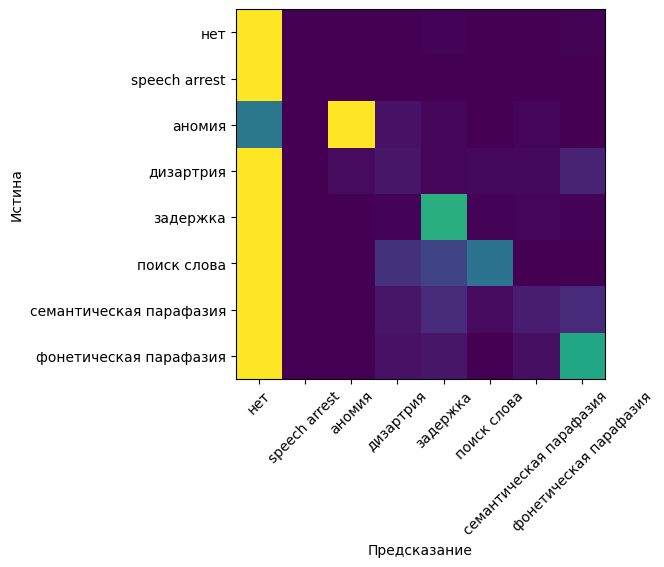

In [67]:
new_pipeline = Pipeline([
        ('counter', ReplacementCounter(dataset_2.columns)),
        ('classifier', basic_model)
])

X = dataset_2[['Stimulus', 'Response_annot',
               'RT_start', 'relative_length',
               'insertions', 'deletions', 'replacements']]
y = dataset_2['error_type_label']

_ = evaluate(X, y, new_pipeline)


## Отдельные замены, вставки и удаления

In [68]:
class EditopsCounter(ReplacementCounter):
    @staticmethod
    def _get_editop_string(type_: str,
                            i_source: int, 
                            i_destination: int,
                            source: str,
                            destination: str) -> str:
            if type_ == 'delete':
                return f'{type_}_{source[i_source]}'
            if type_ == 'insert':
                return f'{type_}_{destination[i_destination]}'
            return f'{type_}_{source[i_source]}'\
                   f'_{destination[i_destination]}'
    
    def _counts(self, X):
        if not ('Stimulus' in X.columns and\
                'Response_annot' in X.columns and\
                (not self.use_transcription or \
                 'Response_transcription_annot' in X.columns
                 )):
            raise TypeError('Нет ожидаемых колонок')
        new_rows = []
        for row in X\
            .with_row_index('id')\
            .to_dicts():
            pairs = Counter()
            # здесь был очень большой баг
            pairs.update([self._get_editop_string(
                            type_, i1, i2,
                            row['Stimulus'],
                            row['Response_annot']) \
                        for type_, i1, i2 in Levenshtein.editops(
                            row['Stimulus'],
                            row['Response_annot'])]
                        )
            
            if self.use_transcription:
                pairs.update([self._get_editop_string(
                                type_, i1, i2,
                                row['Stimulus'],
                                row['Response_transcription_annot'])\
                                +'_t' \
                            for type_, i1, i2 in Levenshtein.editops(
                                row['Stimulus'],
                                row['Response_transcription_annot'])]
                            )
            row.update(pairs.items())
            new_rows.append(row)
        return pl.from_dicts(new_rows, infer_schema_length=2**32)


Класс			Prec.	Rec.	F1
нет			0.9364	0.9885	0.9618
speech arrest		0.8600	0.8000	0.8016
аномия			0.7622	0.7322	0.7450
дизартрия		0.2546	0.0355	0.0607
задержка		0.7240	0.4012	0.5144
поиск слова		0.5781	0.4939	0.5162
семантическая парафазия	0.3763	0.1653	0.2275
фонетическая парафазия	0.6497	0.4016	0.4911


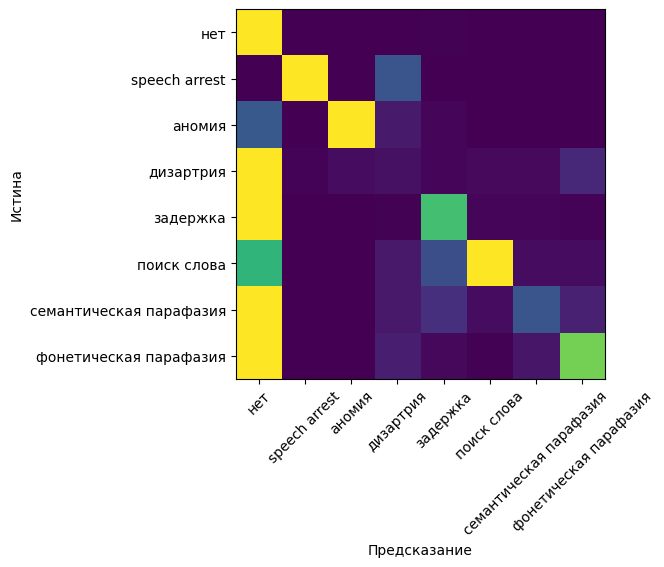

In [69]:
X = dataset_2[['Stimulus', 'Response_annot',
               'RT_start', 'relative_length',
               'insertions', 'deletions', 'replacements']]
y = dataset_2['error_type_label']

new_pipeline = Pipeline([
        ('counter', EditopsCounter(X.columns)),
        ('classifier', basic_model)
])

_ = evaluate(X, y, new_pipeline)


c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-Individuals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Класс			Prec.	Rec.	F1
нет			0.1150	0.0982	0.1055
аномия			0.8833	0.8214	0.8459
дизартрия		0.5973	0.5590	0.5728
задержка		0.8358	0.8467	0.8406
поиск слова		0.6476	0.4436	0.5063
семантическая парафазия	0.3868	0.4105	0.3917
фонетическая парафазия	0.6150	0.7080	0.6564


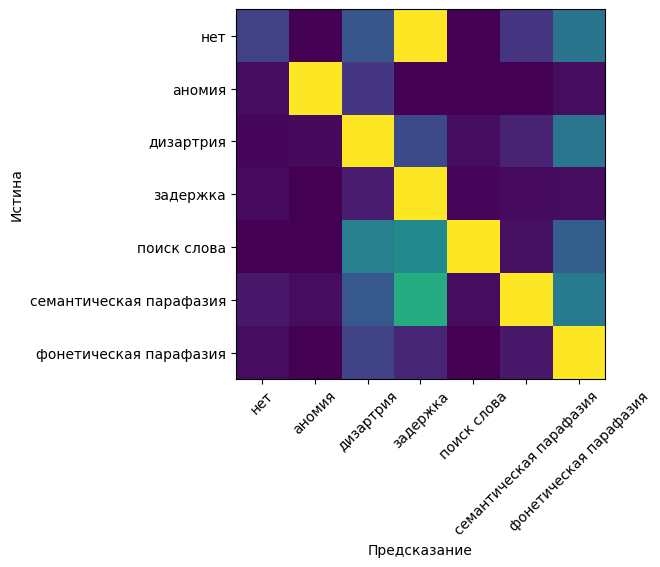

In [70]:
X = dataset_2_t[['Stimulus', 'Response_annot',
                 'Response_transcription_annot',
               'RT_start', 'relative_length',
               'insertions', 'deletions', 'replacements',
               'insertions_transcription',
               'deletions_transcription',
               'replacements_transcription']]
y = dataset_2_t['error_type_label']

new_pipeline = Pipeline([
        ('counter', EditopsCounter(X.columns, use_transcription=True)),
        ('classifier', basic_model)
])

_ = evaluate(X, y, new_pipeline)


### Рефакторинг

Рефакторинг всего, что есть выше, в `BaseEstimator`.

In [10]:
from collections.abc import Sequence, Collection
from typing import Any

from sklearn.exceptions import NotFittedError

class FeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, column_names: Sequence[str] = [],
                 max_editops: int = 10000,
                 force_use_transcription: bool = False,
                 stop_words: list[str] = ['нрзб']):
        '''
        :param column_names: Метки столбцов набора данных, если
            подаётся стуктура данных без них.

        :param max_editops: Максимальное количество выдаваемых в
            качестве признаков операций редактирования.

        :param force_use_transcription: Использовать ли транскрипцию при
            её остсутствии у части записей. Если `True`, вместо 
            отсутствующих транскрипций используются пустые строки. Если 
            `False`, транскрипции используются только при их наличии у
            всех записей.
        
        :param stop_words: Набор подстрок, которые следует удалить из
            транскриптов перед извлечением признаков.
        '''
        self.fit_ = False
        self.column_names = column_names
        self.max_editops = max_editops
        self.force_use_transcription = force_use_transcription
        self.use_transcription = self.force_use_transcription
        self.stop_words = stop_words
        self._stop_words_replacements = [''] * len(stop_words)

    def _clean(self, X: pl.DataFrame) -> pl.DataFrame:
        '''
        Подготавливает колонки с исходными данными: заполняет пропуски
        и очищает `'Response_annot'` от небукв и стопслов.
        '''
        return X\
            .with_columns( # заполнение пропусков
                pl.col('RT_start').fill_null(strategy='zero'),
                pl.col('Response_annot')\
                    .fill_null('')\
                    # очистка
                    .str.to_lowercase()\
                    .str.strip_chars()\
                    .str.replace_all(r'[^а-яё ]', '')\
                    .str.replace_many(self.stop_words,
                                      self._stop_words_replacements)\
                    .str.replace_all(r'\s+', ' '),
                pl.col('Response_transcription_annot').fill_null('')
            )

    
    def _get_relative_lengths(self, X: pl.DataFrame) -> pl.DataFrame:
        '''
        Рассчитать длины ответа и транскрипции ответа по отношению к
        стимулу.

        :param X: Датафрейм с колонками `'Stimulus'`,
          `'Response_annot'` и `'Response_transcription_annot'`.

        :returns: Новый датафрейм с единственной колонкой 
          `'relative_length'` или с двумя — с ней и с 
          `'relative_length_transcription'`.
        '''
        X = X\
            .with_columns( # относительная длина
                            (pl.col('Response_annot').str.len_chars()/
                            pl.col('Stimulus').str.len_chars())\
                        .fill_null(0)\
                        .alias('relative_length')
            )
        selection: list[str] = ['relative_length']
        if self.use_transcription:
            X = X.with_columns( # относительная длина транскрипции
                (pl.col('Response_transcription_annot').str.len_chars()/
                pl.col('Stimulus').str.len_chars())\
                .fill_null(0)\
                .alias('relative_length_transcription')
            )
            selection.append('relative_length_transcription')
        return X[selection]

    @staticmethod
    def _get_editop_string(type_: str,
                               i_source: int, 
                               i_destination: int,
                               source: str,
                               destination: str) -> str:
            if type_ == 'delete':
                return f'{type_}_{source[i_source]}'
            if type_ == 'insert':
                return f'{type_}_{destination[i_destination]}'
            return f'{type_}_{source[i_source]}'\
                   f'_{destination[i_destination]}'

    def _editop_counts(self, X: pl.DataFrame) -> pl.DataFrame:
        '''
        Считает количество операций редактирования для каждой пары
        символов.

        :param X: Датафрейм со столбцами `'Stimulus'`,
         `'Response_annot'` и, если нужно,
         `'Response_transcription_annot'`

        :returns: Новый датафрейм со столбцами для каждой 
         операции редактирования с каждой парой символов.
        '''
        if not ('Stimulus' in X.columns and\
                'Response_annot' in X.columns and\
                (not self.use_transcription or \
                 'Response_transcription_annot' in X.columns
                 )):
            raise TypeError('Нет ожидаемых колонок для подсчёта отдель'\
                            'ных операций редактирования.')
        new_rows: list[dict[str, int]] = []
        
        for row in X\
            .to_dicts(): # iter_rows()
            pairs: Counter[str] = Counter()
            pairs.update([self._get_editop_string(
                            type_, i1, i2,
                            row['Stimulus'],
                            row['Response_annot']) \
                        for type_, i1, i2 in Levenshtein.editops(
                            row['Stimulus'],
                            row['Response_annot'])]
                        )
            
            if self.use_transcription:
                pairs.update(['T' + self._get_editop_string(
                                type_, i1, i2,
                                row['Stimulus'],
                                row['Response_transcription_annot'])\
                            for type_, i1, i2 in Levenshtein.editops(
                                row['Stimulus'],
                                row['Response_transcription_annot'])]
                            )
                
            new_rows.append(dict(pairs))
        # print(new_rows[319])
        output = pl.from_dicts(new_rows,
                               infer_schema_length=2**32)
        # display(output[319])
        # display(output[319].sum_horizontal())
        # output = output.fill_null(0)
        # display(output[319])
        # display(output[319].sum_horizontal())
        return output

    def fit(self, X: pl.DataFrame | np.ndarray, y: Any = None):
        if type(X) != pl.DataFrame:
            X = pl.from_numpy(X, self.column_names)

        self.use_transcription = self.force_use_transcription or not\
            X.get_column('Response_transcription_annot').is_null().any()
        X = self._clean(X)

        # определение самых частотных операций в датасете, на котором
        # преобразователь фиттится
        X = self._editop_counts(X)
        self.top_editop_columns: list[str] = \
                    X.select(pl.all()\
                        .exclude(pl.String)\
                        .sum()
                    )\
                    .unpivot()\
                    .sort('value', descending=True)\
                    .head(self.max_editops)\
                    .get_column('variable')\
                    .to_list()

        self.fit_ = True
        return self

    def transform(self, X: pl.DataFrame | np.ndarray):
        if not self.fit_:
            raise NotFittedError
        if type(X) != pl.DataFrame:
            X = pl.from_numpy(X, self.column_names)

        X = self._clean(X)
        relative_lengths = self._get_relative_lengths(X)

        counts = self._editop_counts(X)

        
        # нормализованные количества операций
        prefixes = ['Tdelete', 'Tinsert', 'Treplace',
                    'delete', 'insert', 'replace']
        stimulus_lengths = X.get_column('Stimulus').str.len_chars()
        normalized_total_editops = []
        for prefix in prefixes:
            columns_to_sum = [c
                           for c in counts.columns
                           if c.startswith(f'{prefix}_')]
            if columns_to_sum:
                column = \
                (counts.select(columns_to_sum)\
                        .sum_horizontal() /
                          stimulus_lengths)\
                    .alias(prefix + '_normalized_total')
                normalized_total_editops.append(column)

        normalized_total_editops = \
            pl.DataFrame(normalized_total_editops)
        

        counts = counts.with_columns(
                [pl.lit(0, dtype=pl.Int64).alias(c) 
                for c in self.top_editop_columns
                if c not in counts.columns])\
            .select(self.top_editop_columns)

        X = pl.concat([X, relative_lengths,
                normalized_total_editops, counts], how='horizontal') \
            .drop(pl.selectors.string()) \
            .fill_null(0)
        
        return X


Класс			Prec.	Rec.	F1
нет			0.9362	0.9887	0.9617
speech arrest		0.8600	0.8000	0.8016
аномия			0.7396	0.7322	0.7328
дизартрия		0.2566	0.0355	0.0608
задержка		0.7243	0.4012	0.5144
поиск слова		0.5956	0.4424	0.4910
семантическая парафазия	0.4103	0.1868	0.2550
фонетическая парафазия	0.6679	0.4055	0.4990


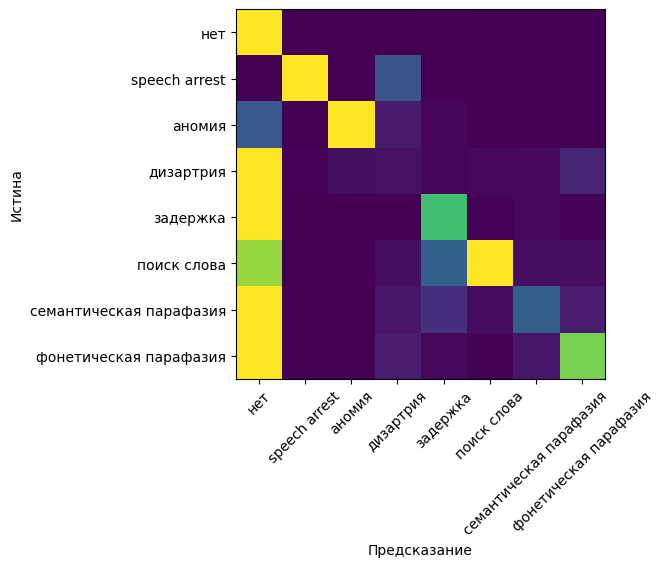

In [95]:
dataset_0_raw = dataset[[
    'Stimulus',
    'RT_start',
    'Response_annot',
    'Response_transcription_annot',
    'error_type_label'
    ]]

X = dataset_0_raw.drop('error_type_label')
y = dataset_0_raw['error_type_label']

new_pipeline_2 = Pipeline([
        ('feature_extractor', FeatureExtractor()),
        ('classifier', basic_model)
])

_ = evaluate(X, y, new_pipeline_2)



Класс			Prec.	Rec.	F1
нет			0.0778	0.0582	0.0656
аномия			0.8798	0.8214	0.8431
дизартрия		0.6040	0.5661	0.5818
задержка		0.8295	0.8576	0.8422
поиск слова		0.6404	0.5236	0.5442
семантическая парафазия	0.3736	0.3676	0.3593
фонетическая парафазия	0.6379	0.6836	0.6587


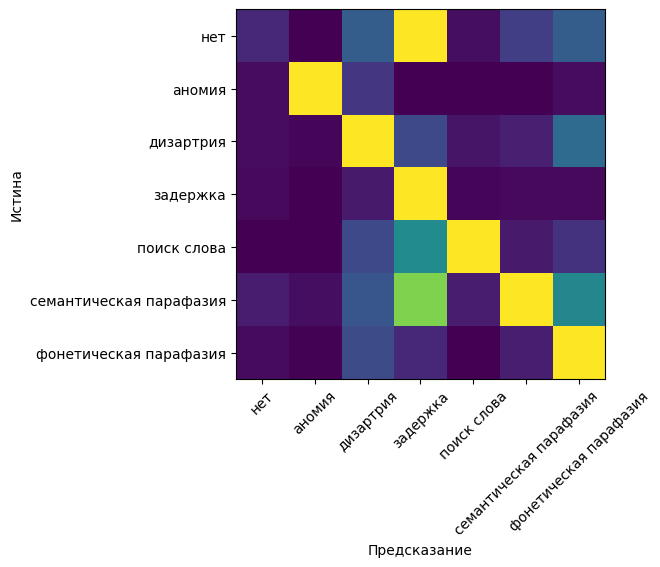

In [96]:
dataset_0_raw = dataset[[
    'Stimulus',
    'RT_start',
    'Response_annot',
    'Response_transcription_annot',
    'error_type_label'
    ]].filter(pl.col('Response_transcription_annot').is_not_null())

X = dataset_0_raw.drop('error_type_label')
y = dataset_0_raw['error_type_label']

new_pipeline_2 = Pipeline([
        ('feature_extractor', FeatureExtractor()),
        ('classifier', basic_model)
])

_ = evaluate(X, y, new_pipeline_2)



# Положение ответов в языке

До этого я анализировал только то, как ответ соотносится со стимулом. Тем не менее, семантическую и фонетическую парафазию нельзя определить в отрыве от всего остального языка, в частности, так не делалось при человеческой разметке.

## Формальная близость к настоящим словам

Предполагается, что если ответ формально близок к какому-либо существующему слову и далёк от стимула — то это семантическая парафазия, если ближе к стимулу — то фонетическая.

Будем использовать наиболее частотные существительные и глагольные формы по Araneum Russicum III Maximum (Russian, 19.03) 19.8 G. Будет определяться расстояние Левенштейна между ответом, стимулом и ближайшим к ответу словом из корпуса. Также учитывается разность логарифмов частотностей кандидата в ответы и стимула. Это нужно, чтобы исключить ложное попадание в слишком редкое или слишком частотное слово при фактической фонетической парафазии; также предполагается, что при семантической парафазии заменяющее слово будет примерно так же частотно, как стимул.

In [79]:
aranea_word_list = pl.read_csv('../data/word_frequencies/'
                               'AranRusi_a.tsv',
                               separator='\t')\
                    .with_columns(pl.col('Frequency')\
                                    .log(base=2)\
                                    .alias('log_Frequency'),
                                  pl.col('word')\
                                    .fill_null('')\
                                    .str.to_lowercase()\
                                    .str.replace_all(r'[^а-яё ]', '')\
                                    .str.replace_all('нрзб', ''))\
                        .filter(pl.col('word').str.len_chars() > 0)\
                        .unique(pl.col('word'))


## Оптимизация

Тут нужно посчитать медленным способом на какой-то подвыборке на которой это вообще получится, затем на той же быстрым, затем посчитать метрики.


In [11]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:


word_list_vectorizer = CountVectorizer(analyzer='char',
                                       dtype=np.int8)
word_list_vectors = word_list_vectorizer.fit_transform(
    aranea_word_list['word']).toarray()


In [102]:
queries = pl.concat([dataset_0['Response_annot'],\
                            dataset_0['Stimulus']]).unique().fill_null('')\
                    .str.to_lowercase()\
                    .str.strip_chars()\
                    .str.replace_all(r'[^а-яё ]', '')\
                    .str.replace_many(('нрзб', 'это'), '')\
                    .str.replace_all(r'\s+', ' ')


C:\Users\Vlad\AppData\Local\Temp\ipykernel_17696\3783062510.py:6: DeprecationWarning: `str.replace_many` with a flat string datatype is deprecated.
please use `implode` to return to previous behavior.
See https://github.com/pola-rs/polars/issues/22149 for more information.
  .str.replace_many(('нрзб', 'это'), '')\


In [17]:
from rapidfuzz.process import cdist

In [ ]:


golden_distances = cdist(queries,
                    aranea_word_list['word'],
                    scorer=Levenshtein.distance,
                    dtype=np.int8)


In [104]:
k = 5

In [105]:
golden_topk_indices = np.sort(golden_distances\
                .argpartition(axis=1, kth=k-1)[:, :k],
                axis=1)


In [106]:
golden_topk_indices.shape

(953, 5)

In [107]:
example_index = 123

In [108]:
golden_topk_indices[example_index]

array([  7230,  71478, 231006, 276701, 284230])

In [109]:
golden_distances[example_index, golden_topk_indices[example_index]]

array([5, 5, 4, 5, 6], dtype=int8)

In [110]:
queries[example_index]

'качели качели'

In [111]:
aranea_word_list[golden_topk_indices[example_index]]

word,Frequency,log_Frequency
str,i64,f64
"""течеискатели""",8,3.0
"""картликахети""",4,2.0
"""качеликарусели""",5,2.321928
"""кабелеискатель""",3,1.584963
"""течеискатель""",11,3.459432


In [237]:
query_vectors = word_list_vectorizer.transform(queries).toarray()


In [14]:
import faiss

In [ ]:


word_list_vectors = np.ascontiguousarray(word_list_vectors)\
                                                   .astype('float32')
query_vectors = np.ascontiguousarray(query_vectors)\
                                                    .astype('float32')

word_list_vectors_8 = np.ascontiguousarray(word_list_vectors)\
                                                   .astype('int8')
query_vectors_8 = np.ascontiguousarray(query_vectors)\
                                                    .astype('int8')

indexL2 = faiss.IndexFlatL2(word_list_vectors.shape[1])
indexL2.add(word_list_vectors)

indexL1 = faiss.IndexFlat(word_list_vectors.shape[1])
indexL1.add(word_list_vectors)

indexL2_8 = faiss.IndexFlatL2(word_list_vectors_8.shape[1])
indexL2_8.add(word_list_vectors_8)

indexL1_8 = faiss.IndexFlat(word_list_vectors_8.shape[1])
indexL1_8.add(word_list_vectors_8)

In [247]:
%%timeit -r 28
nn_candidates = indexL1.search(query_vectors, k=1000) 


The slowest run took 4.11 times longer than the fastest. This could mean that an intermediate result is being cached.
1.46 s ± 630 ms per loop (mean ± std. dev. of 28 runs, 1 loop each)


In [248]:
%%timeit -r 28
nn_candidates = indexL2.search(query_vectors, k=1000) 


1.34 s ± 404 ms per loop (mean ± std. dev. of 28 runs, 1 loop each)


In [249]:
%%timeit -r 28
nn_candidates = indexL1_8.search(query_vectors_8, k=1000) 


1.18 s ± 118 ms per loop (mean ± std. dev. of 28 runs, 1 loop each)


In [250]:
%%timeit -r 28
nn_candidates = indexL2_8.search(query_vectors_8, k=1000) 


1.16 s ± 148 ms per loop (mean ± std. dev. of 28 runs, 1 loop each)


In [257]:
index = indexL2_8
query_vectors = query_vectors_8

In [259]:
nn_candidates = index.search(query_vectors, k=5)


In [267]:
nn_candidates[0][example_index]

array([4., 5., 5., 5., 5.], dtype=float32)

In [268]:
nn_candidates[1][example_index]

array([231006,   4382,  33993,  93840, 158376])

In [269]:
aranea_word_list[nn_candidates[1][example_index]]

word,Frequency,log_Frequency
str,i64,f64
"""качеликарусели""",5,2.321928
"""алексейчика""",2,1.0
"""чекалки""",2,1.0
"""какчикели""",4,2.0
"""наклеечки""",10,3.321928


Метрика для оценки качества найденных кандидатов

In [270]:
def metric(y_true: np.ndarray, y_pred: np.ndarray, k: int = 5)\
      -> np.ndarray:
    # y_true = np.sort(y_true, axis=-1)
    y_pred = np.partition(y_pred, kth=k - 1, axis=-1)
    mask = (np.sort(y_pred[:, :k]) <= y_true[:, :k])
    first_false = np.argmin(mask, axis=-1)
    all_true = np.all(mask, axis=-1)
    return np.where(all_true, k, first_false) / k

In [271]:
metric_test_true = np.array([[1, 2, 3, 4, 5],
                             [1, 2, 3, 4, 5],
                             [1, 2, 3, 4, 5]])

metric_test_pred = np.array([[1, 2, 3, 4, 5],
                             [2, 3, 4, 4, 5],
                             [1, 2, 4, 4, 5]])


In [272]:
metric(metric_test_true, metric_test_pred)

array([1. , 0. , 0.4])

In [273]:
nn_candidate_indices = index.search(query_vectors, k=1000)[1]


In [128]:
golden_distances_sorted = np.sort(golden_distances,
                                    axis=1)

In [274]:
golden_distances_arranged_by_nn = np.take_along_axis(
    golden_distances, indices=nn_candidate_indices, axis=1
)

In [172]:
golden_distances.shape

(953, 421238)

In [191]:
nn_candidate_indices.shape

(953, 1000)

In [275]:
from tqdm import tqdm
metric_means: dict[int, list[float]] = {}

for k in range(1, 5+1):
    metric_means[k] = [0]
    for radius in tqdm(range(5, 1000)):
        metric_means[k].append(
                        metric(golden_distances_sorted[:, :radius],
                        golden_distances_arranged_by_nn[:, :radius], 
                        k=k)\
                .mean())


100%|██████████| 995/995 [00:03<00:00, 261.18it/s] 


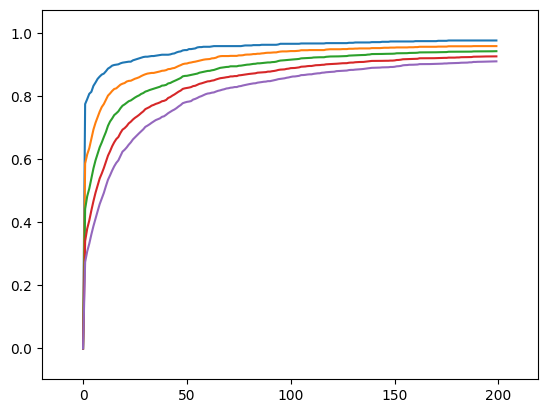

In [276]:
from matplotlib.pyplot import plot, margins

for k, v in metric_means.items():
    plot(v[0:200], label=k)

margins(x=0.1, y=0.1) 


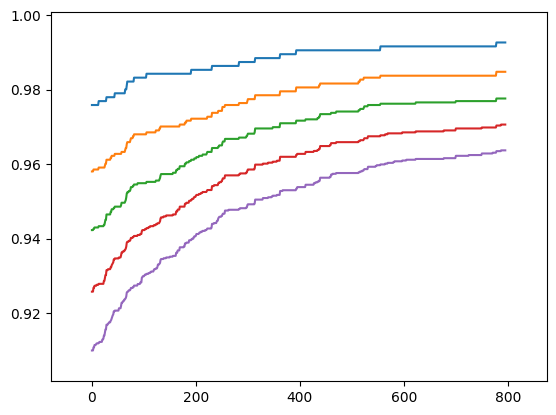

In [277]:
for k, v in metric_means.items():
    plot(v[200:1000], label=k)

margins(x=0.1, y=0.1)

## Интеграция в feature extractor

In [18]:
from collections.abc import Sequence, Collection
from typing import Any

from sklearn.exceptions import NotFittedError

class FeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, column_names: Sequence[str] = [],
                 max_editops: int = 10000,
                 force_use_transcription: bool = False,
                 stop_words: list[str] | None = None,
                 word_list_path: str = '../data/word_frequencies/'
                                       'AranRusi_a.tsv',
                 word_list_cutoff: int | None = None,
                 word_list_stop_words: list[str] | None = None,
                 word_list_n_candidates: int = 200,
                 word_list_radius: int = 3):
        '''
        :param column_names: Метки столбцов набора данных, если
            подаётся стуктура данных без них.

        :param max_editops: Максимальное количество выдаваемых в
            качестве признаков операций редактирования.

        :param force_use_transcription: Использовать ли транскрипцию при
            её остсутствии у части записей. Если `True`, вместо 
            отсутствующих транскрипций используются пустые строки. Если 
            `False`, транскрипции используются только при их наличии у
            всех записей.
        
        :param stop_words: Набор подстрок, которые следует удалить из
            транскриптов перед извлечением признаков.

        :param word_list_path: Путь к TSV файлу, содержащему частотный
            список слов в виде колонок `'words'` со словами и 
            `'Frequency'` — с абсолютной частотностью.

        :param word_list_cutoff: Сколько первых уникальных строк        
            частотного списка слов использовать. Если `None`, то
            используется весь список.

        :param word_list_stop_words: Набор подстрок, которые следует
            удалить из транскрипта только при поиске по частотному
            списку.

        :param word_list_n_candidates: Количество ближайших кандидатов
            из частотного списка слов для расчёта расстояния
            Левенштейна.

        :param word_list_radius: Количество ближайших слов среди
            кандидатов из частотного списка слов, для которых
            будет посчитана метрика.
        '''
        self.fit_ = False
        self.column_names = column_names
        self.max_editops = max_editops
        self.force_use_transcription = force_use_transcription
        self.use_transcription = self.force_use_transcription
        self.stop_words = stop_words or ['нрзб']
        self._stop_words_replacements = [''] * len(self.stop_words)
        self.word_list_stop_words = word_list_stop_words or ['это']
        self._word_list_stop_words_replacements = \
                                [''] * len(self.word_list_stop_words)
        self.word_list_n_candidates = word_list_n_candidates
        self.word_list_radius = word_list_radius

        # TODO: загрузка частотного списка из файла любого формата с
        # именованными колонками

        self.word_list = pl.read_csv(word_list_path,
                        separator='\t')\
                    .sort('Frequency', descending=True)\
                    .with_columns(pl.col('Frequency')\
                            .log(base=2)\
                            .alias('w_log_Frequency'),
                            pl.col('word')\
                            .fill_null('')\
                            .str.to_lowercase()\
                            .str.replace_all(r'[^а-яё ]', ''))\
                .filter(pl.col('word').str.len_chars() > 0)\
                .unique(pl.col('word'))[:word_list_cutoff]
        
        self.word_list_vectorizer = CountVectorizer(dtype=np.int8,
                                                    analyzer='char')
        
        self.word_list_vectors = np.ascontiguousarray(
                                 self.word_list_vectorizer\
                                 .fit_transform(self.word_list['word'])\
                                 .toarray())
        
        self.word_list_nearest_neighbors = \
                        faiss.IndexFlatL2(self.word_list_vectors\
                                          .shape[1])
        
        self.word_list_nearest_neighbors.add(self.word_list_vectors)

    def _clean(self, X: pl.DataFrame) -> pl.DataFrame:
        '''
        Подготавливает колонки с исходными данными: заполняет пропуски
        и очищает `'Response_annot'` от небукв и стопслов.
        '''
        return X\
            .with_columns( # заполнение пропусков
                pl.col('RT_start').fill_null(strategy='zero'),
                pl.col('Response_annot')\
                    .fill_null('')\
                    # очистка
                    .str.to_lowercase()\
                    .str.strip_chars()\
                    .str.replace_all(r'[^а-яё ]', '')\
                    .str.replace_many(self.stop_words,
                                      self._stop_words_replacements)\
                    .str.replace_all(r'\s+', ' '),
                pl.col('Response_transcription_annot').fill_null('')
            )

    
    def _get_relative_lengths(self, X: pl.DataFrame) -> pl.DataFrame:
        '''
        Рассчитать длины ответа и транскрипции ответа по отношению к
        стимулу.

        :param X: Датафрейм с колонками `'Stimulus'`,
          `'Response_annot'` и `'Response_transcription_annot'`.

        :returns: Новый датафрейм с единственной колонкой 
          `'relative_length'` или с двумя — с ней и с 
          `'relative_length_transcription'`.
        '''
        X = X\
            .with_columns( # относительная длина
                            (pl.col('Response_annot').str.len_chars()/
                            pl.col('Stimulus').str.len_chars())\
                        .fill_null(0)\
                        .alias('relative_length')
            )
        selection: list[str] = ['relative_length']
        if self.use_transcription:
            X = X.with_columns( # относительная длина транскрипции
                (pl.col('Response_transcription_annot').str.len_chars()/
                pl.col('Stimulus').str.len_chars())\
                .fill_null(0)\
                .alias('relative_length_transcription')
            )
            selection.append('relative_length_transcription')
        return X[selection]

    @staticmethod
    def _get_editop_string(type_: str,
                               i_source: int, 
                               i_destination: int,
                               source: str,
                               destination: str) -> str:
            if type_ == 'delete':
                return f'{type_}_{source[i_source]}'
            if type_ == 'insert':
                return f'{type_}_{destination[i_destination]}'
            return f'{type_}_{source[i_source]}'\
                   f'_{destination[i_destination]}'

    def _editop_counts(self, X: pl.DataFrame) -> pl.DataFrame:
        '''
        Считает количество операций редактирования для каждой пары
        символов.

        :param X: Датафрейм со столбцами `'Stimulus'`,
         `'Response_annot'` и, если нужно,
         `'Response_transcription_annot'`

        :returns: Новый датафрейм со столбцами для каждой 
         операции редактирования с каждой парой символов.
        '''
        if not ('Stimulus' in X.columns and\
                'Response_annot' in X.columns and\
                (not self.use_transcription or \
                 'Response_transcription_annot' in X.columns
                 )):
            raise TypeError('Нет ожидаемых колонок для подсчёта отдель'\
                            'ных операций редактирования.')
        new_rows: list[dict[str, int]] = []

        stimuli = X['Stimulus']
        responses = X['Response_annot']
        for i in range(X.height):
            pairs: Counter[str] = Counter()
            pairs.update([self._get_editop_string(
                            type_, i1, i2,
                            stimuli[i],
                            responses[i]) \
                        for type_, i1, i2 in Levenshtein.editops(
                            stimuli[i],
                            responses[i])]
                        )
            
            if self.use_transcription:
                pairs.update(['T' + self._get_editop_string(
                                type_, i1, i2,
                                stimuli[i],
                                responses[i])\
                            for type_, i1, i2 in Levenshtein.editops(
                                stimuli[i],
                                responses[i])]
                            )
                
            new_rows.append(dict(pairs))

        output = pl.from_dicts(new_rows,
                               infer_schema_length=2**32)

        return output
    

    def _get_word_list_metrics(self, X: pl.DataFrame):
        pairs = X.select(['Response_annot', 'Stimulus']).unique()

        fallback_frequency = self.word_list['w_log_Frequency'].mode()[0]
        
        pairs_with_frequencies = pairs.join(
            self.word_list.select(['word', 'w_log_Frequency']),
            left_on='Stimulus', right_on='word', how='left'
        ).with_columns(
            pl.col('w_log_Frequency').fill_null(fallback_frequency)
        )

        responses_clean = pairs_with_frequencies['Response_annot']\
                            .str.replace_many(
                                self.word_list_stop_words,
                                self._word_list_stop_words_replacements
                            )

        query_vectors = np.ascontiguousarray(
                                            self.word_list_vectorizer\
                                            .transform(responses_clean)\
                                            .toarray()
                                            )
        
        _, candidate_indices = self.word_list_nearest_neighbors\
                                .search(query_vectors,
                                        k=self.word_list_n_candidates)

        words = self.word_list['word']
        
        radius = self.word_list_radius
        all_distances = np.empty((responses_clean.len(), radius),
                                        dtype=np.int8)
        all_frequency_differences = np.empty((responses_clean.len(),
                                              radius))
        
        for i in range(responses_clean.len()):
            if not responses_clean[i]: # для пустых ответов
                all_distances[i, :] = 127
                all_frequency_differences[i, :] = 127.
                continue
            distances = (cdist([responses_clean[i]],
                        self.word_list['word'][candidate_indices[i]]) \
                        / (len(responses_clean[i]))).squeeze()
                                
            frequency_penalties = \
             np.abs(
              self.word_list['w_log_Frequency'][candidate_indices[i]]\
                                                           .to_numpy() -
              pairs_with_frequencies['w_log_Frequency'][i]
            )
            distances.partition(radius - 1)
            indices_to_include = np.argsort(distances[:radius])
            all_distances[i] = distances[indices_to_include]
            all_frequency_differences[i] = frequency_penalties\
                                               [indices_to_include]

        distance_column_names = [f'word_list_distance_{i}'
                                 for i in range(radius)]
        
        frequency_difference_column_names = \
                                [f'word_list_frequency_difference_{i}'
                                 for i in range(radius)]
        
        results = pl.DataFrame(all_distances,
                              schema=distance_column_names,
                              orient='row').hstack(
                  pl.DataFrame(all_frequency_differences,
                              schema=frequency_difference_column_names,
                              orient='row')  
                              ).hstack(pairs)

        return (
            X.join(results,
                   on=['Response_annot', 'Stimulus'],
                   how='left')
            .select(distance_column_names + \
                    frequency_difference_column_names)
        )

    def fit(self, X: pl.DataFrame | np.ndarray, y: Any = None):
        if type(X) != pl.DataFrame:
            X = pl.from_numpy(X, self.column_names)

        self.use_transcription = self.force_use_transcription or not\
            X.get_column('Response_transcription_annot').is_null().any()
        X = self._clean(X)

        # определение самых частотных операций в датасете, на котором
        # преобразователь фиттится
        X = self._editop_counts(X)
        self.top_editop_columns: list[str] = \
                    X.select(pl.all()\
                        .exclude(pl.String)\
                        .sum()
                    )\
                    .unpivot()\
                    .sort('value', descending=True)\
                    .head(self.max_editops)\
                    .get_column('variable')\
                    .to_list()

        self.fit_ = True
        return self

    def transform(self, X: pl.DataFrame | np.ndarray):
        if not self.fit_:
            raise NotFittedError
        if type(X) != pl.DataFrame:
            X = pl.from_numpy(X, self.column_names)

        X = self._clean(X)
        relative_lengths = self._get_relative_lengths(X)

        counts = self._editop_counts(X)

        
        # нормализованные количества операций
        prefixes = ['Tdelete', 'Tinsert', 'Treplace',
                    'delete', 'insert', 'replace']
        stimulus_lengths = X.get_column('Stimulus').str.len_chars()
        normalized_total_editops = []
        for prefix in prefixes:
            columns_to_sum = [c
                           for c in counts.columns
                           if c.startswith(f'{prefix}_')]
            if columns_to_sum:
                column = \
                (counts.select(columns_to_sum)\
                        .sum_horizontal() /
                          stimulus_lengths)\
                    .alias(prefix + '_normalized_total')
                normalized_total_editops.append(column)

        normalized_total_editops = \
            pl.DataFrame(normalized_total_editops)
        

        counts = counts.with_columns(
                [pl.lit(0, dtype=pl.Int64).alias(c) 
                for c in self.top_editop_columns
                if c not in counts.columns])\
            .select(self.top_editop_columns)
        
        word_list_metrics = self._get_word_list_metrics(X)

        X = pl.concat([X, relative_lengths,
                normalized_total_editops, counts, word_list_metrics],
                how='horizontal') \
            .drop(pl.selectors.string()) \
            .fill_null(0)
        
        return X


Класс			Prec.	Rec.	F1
нет			0.9376	0.9875	0.9619
speech arrest		0.8600	0.8000	0.8016
аномия			0.7696	0.7439	0.7524
дизартрия		0.4690	0.1065	0.1733
задержка		0.7076	0.3942	0.5048
поиск слова		0.6010	0.4424	0.5022
семантическая парафазия	0.4452	0.1939	0.2608
фонетическая парафазия	0.6183	0.4131	0.4914


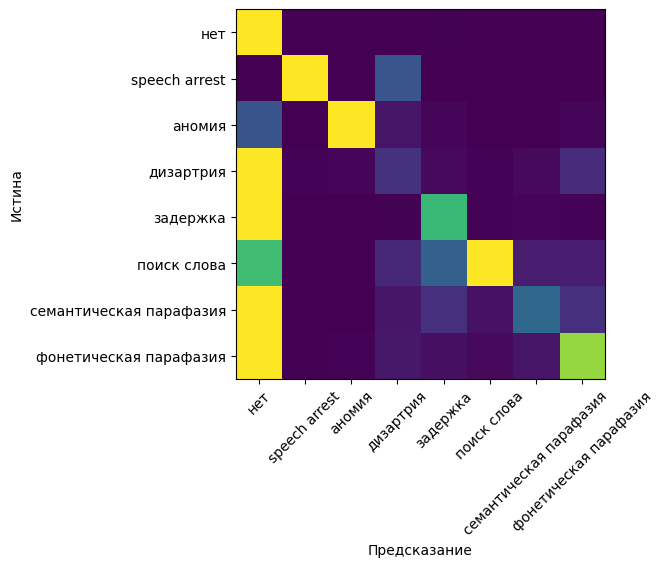

In [19]:
dataset_0_raw = dataset[[
    'Stimulus',
    'RT_start',
    'Response_annot',
    'Response_transcription_annot',
    'error_type_label'
    ]]

X = dataset_0_raw.drop('error_type_label')
y = dataset_0_raw['error_type_label']

new_pipeline_3 = Pipeline([
        ('feature_extractor', FeatureExtractor()),
        ('classifier', basic_model)
])

_ = evaluate(X, y, new_pipeline_3)



In [20]:
new_pipeline_3['classifier'].feature_names_in_[np.argsort(-new_pipeline_3['classifier'].feature_importances_)]

array(['RT_start', 'insert_ ', 'replace_normalized_total',
       'word_list_frequency_difference_0',
       'word_list_frequency_difference_2', 'insert_о', 'delete_ь',
       'delete_normalized_total', 'insert_normalized_total',
       'word_list_frequency_difference_1', 'insert_р', 'insert_т',
       'insert_л', 'word_list_distance_0', 'relative_length', 'insert_к',
       'delete_р', 'insert_ю', 'insert_п', 'insert_а', 'replace_с_д',
       'replace_у_а', 'replace_ш_ж', 'insert_е', 'word_list_distance_1',
       'insert_ч', 'replace_у_ё', 'word_list_distance_2', 'replace_р_о',
       'delete_а', 'replace_б_о', 'insert_н', 'replace_е_к',
       'replace_в_т', 'delete_и', 'delete_е', 'insert_д', 'replace_и_о',
       'replace_п_н', 'replace_б_в', 'insert_с', 'insert_э',
       'replace_р_ж', 'delete_т', 'replace_к_ч', 'insert_г',
       'replace_и_е', 'delete_у', 'replace_в_п', 'delete_м', 'delete_г',
       'insert_у', 'insert_ж', 'delete_я', 'replace_а_ё', 'replace_ж_ ',
       'del

Класс			Prec.	Rec.	F1
нет			0.2067	0.0782	0.1015
аномия			0.8007	0.7964	0.7953
дизартрия		0.4355	0.3873	0.4066
задержка		0.7350	0.8421	0.7845
поиск слова		0.7468	0.5036	0.5478
семантическая парафазия	0.4630	0.4210	0.4242
фонетическая парафазия	0.5113	0.4246	0.4522


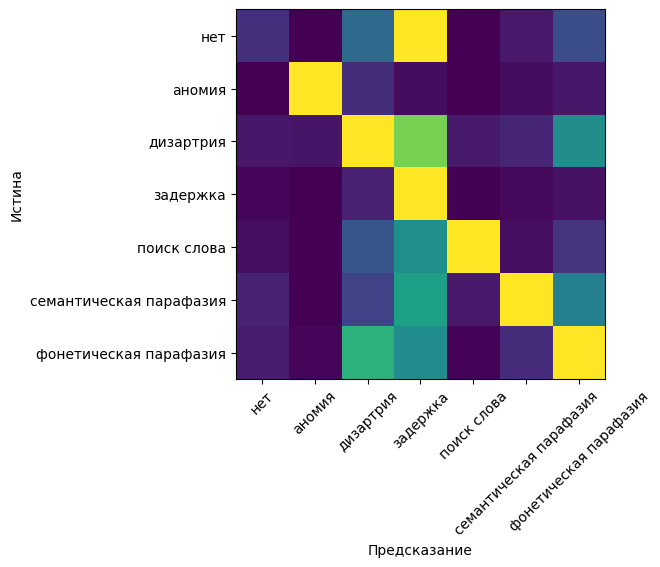

In [21]:
dataset_0_raw = dataset[[
    'Stimulus',
    'RT_start',
    'Response_annot',
    'Response_transcription_annot',
    'error_type_label'
    ]].filter(pl.col('Response_transcription_annot').is_not_null())

X = dataset_0_raw.drop('error_type_label')
y = dataset_0_raw['error_type_label']

new_pipeline_2 = Pipeline([
        ('feature_extractor', FeatureExtractor()),
        ('classifier', basic_model)
])

_ = evaluate(X, y, new_pipeline_2)

